# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nasikhun Amin
- **Email:** nasikhunamin1011@gmail.com
- **ID Dicoding:** nasikhun_amin

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana pengaruh musim dan kondisi cuaca terhadap jumlah penyewaan sepeda?
- Pertanyaan 2: Kapan waktu dengan tingkat penyewaan sepeda tertinggi, dan bagaimana perbedaannya antara hari kerja vs hari libur/akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)


## Data Wrangling

### Gathering Data

In [18]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print('Shape day_df:', day_df.shape)
print('Shape hour_df:', hour_df.shape)

print()
print('5 data teratas day_df:')
print(day_df.head().to_string(index=False))

print()
print('5 data teratas hour_df:')
print(hour_df.head().to_string(index=False))

print()
print('Info day_df:')
day_df.info()

print()
print('Info hour_df:')
hour_df.info()

print()
print('Statistik deskriptif day_df:')
print(day_df.describe(include='all').to_string())

print()
print('Statistik deskriptif hour_df:')
print(hour_df.describe(include='all').to_string())


Shape day_df: (731, 16)
Shape hour_df: (17379, 17)

5 data teratas day_df:
 instant     dteday  season  yr  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  casual  registered  cnt
       1 2011-01-01       1   0     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446     331         654  985
       2 2011-01-02       1   0     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539     131         670  801
       3 2011-01-03       1   0     1        0        1           1           1 0.196364 0.189405 0.437273   0.248309     120        1229 1349
       4 2011-01-04       1   0     1        0        2           1           1 0.200000 0.212122 0.590435   0.160296     108        1454 1562
       5 2011-01-05       1   0     1        0        3           1           1 0.226957 0.229270 0.436957   0.186900      82        1518 1600

5 data teratas hour_df:
 instant     dteday  season  yr  mnth  hr 

**Insight:**
- Data tersedia dalam agregasi harian dan jam, memungkinkan analisis tren makro serta dinamika permintaan per jam.

- Kedua dataset memuat variabel terkait cuaca, kalender, serta variabel target utama `cnt` (total rental), yang terdiri dari dua komponen utama: `casual` dan `registered`.

- Data mencakup periode tahun 2011–2012, sehingga relevan untuk analisis tren temporal, pola musiman, serta perilaku pengguna berdasarkan waktu.

### Assessing Data

In [19]:
missing_day = day_df.isna().sum().to_frame('missing_count')
missing_hour = hour_df.isna().sum().to_frame('missing_count')

duplicate_day = day_df.duplicated().sum()
duplicate_hour = hour_df.duplicated().sum()

dtype_comparison = pd.DataFrame({
    'day_df_dtype': day_df.dtypes.astype(str),
    'hour_df_dtype': hour_df.dtypes.astype(str),
})


def iqr_outlier_summary(df, numeric_cols):
    rows = []
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_pct = (outlier_count / len(df)) * 100

        rows.append({
            'column': col,
            'lower_bound': round(lower, 4),
            'upper_bound': round(upper, 4),
            'outlier_count': int(outlier_count),
            'outlier_pct': round(outlier_pct, 2),
        })

    return pd.DataFrame(rows)


numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
outlier_day = iqr_outlier_summary(day_df, numeric_cols)
outlier_hour = iqr_outlier_summary(hour_df, numeric_cols)

print('Missing values - day_df')
print(missing_day.T.to_string())

print()
print('Missing values - hour_df')
print(missing_hour.T.to_string())

print()
print(f'Duplicate rows day_df: {duplicate_day}')
print(f'Duplicate rows hour_df: {duplicate_hour}')

print()
print('Perbandingan tipe data:')
print(dtype_comparison.to_string())

print()
print('Outlier summary (IQR) - day_df:')
print(outlier_day.to_string(index=False))

print()
print('Outlier summary (IQR) - hour_df:')
print(outlier_hour.to_string(index=False))


Missing values - day_df
               instant  dteday  season  yr  mnth  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  casual  registered  cnt
missing_count        0       0       0   0     0        0        0           0           0     0      0    0          0       0           0    0

Missing values - hour_df
               instant  dteday  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  casual  registered  cnt
missing_count        0       0       0   0     0   0        0        0           0           0     0      0    0          0       0           0    0

Duplicate rows day_df: 0
Duplicate rows hour_df: 0

Perbandingan tipe data:
           day_df_dtype hour_df_dtype
atemp           float64       float64
casual            int64         int64
cnt               int64         int64
dteday           object        object
holiday           int64         int64
hr                  NaN         int64
hum             flo

**Insight:**
- Tidak ditemukan **missing values** pada kedua dataset.
- Tidak terdapat **duplikasi baris**.

- Kolom `dteday` masih bertipe *object* (string) dan perlu dikonversi menjadi tipe `datetime` agar analisis berbasis waktu (time-series) dapat dilakukan secara optimal.

- Berdasarkan pengecekan menggunakan metode **IQR (Interquartile Range)**, teridentifikasi outlier pada beberapa kolom numerik, khususnya variabel cuaca (`hum`, `windspeed`) serta variabel demand utama (`casual`, `registered`, `cnt`). Hal ini perlu ditangani agar tidak mendistorsi hasil analisis lanjutan.

### Cleaning Data

In [20]:
day_clean = day_df.copy()
hour_clean = hour_df.copy()

for df in [day_clean, hour_clean]:
    df['dteday'] = pd.to_datetime(df['dteday'])


def iqr_bounds(df, numeric_cols):
    bounds = {}
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        bounds[col] = (lower, upper)
    return bounds


def winsorize_iqr(df, bounds):
    summary = []
    for col, (lower, upper) in bounds.items():
        before = int(((df[col] < lower) | (df[col] > upper)).sum())
        df[col] = df[col].clip(lower=lower, upper=upper)
        after = int(((df[col] < lower) | (df[col] > upper)).sum())
        summary.append({
            'column': col,
            'lower_bound': round(lower, 4),
            'upper_bound': round(upper, 4),
            'outlier_before': before,
            'outlier_after': after,
        })
    return pd.DataFrame(summary)


# Handle outlier
outlier_handle_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

day_bounds = iqr_bounds(day_clean, outlier_handle_cols)
hour_bounds = iqr_bounds(hour_clean, outlier_handle_cols)

day_outlier_fix = winsorize_iqr(day_clean, day_bounds)
hour_outlier_fix = winsorize_iqr(hour_clean, hour_bounds)

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow',
}
year_map = {0: 2011, 1: 2012}

for df in [day_clean, hour_clean]:
    df['season_name'] = df['season'].map(season_map)
    df['weather_name'] = df['weathersit'].map(weather_map)
    df['year'] = df['yr'].map(year_map)
    df['month_name'] = df['dteday'].dt.month_name()
    df['day_name'] = df['dteday'].dt.day_name()

hour_clean['day_type'] = np.where(hour_clean['workingday'] == 1, 'Working Day', 'Holiday/Weekend')

print('Ringkasan handle outlier (day_clean):')
print(day_outlier_fix.to_string(index=False))

print()
print('Ringkasan handle outlier (hour_clean):')
print(hour_outlier_fix.to_string(index=False))

print()
print('Rentang tanggal hour_clean:', hour_clean['dteday'].min().date(), 's/d', hour_clean['dteday'].max().date())
print('Jumlah baris hour_clean:', len(hour_clean))

print()
print('Contoh data setelah cleaning (hour_clean):')
print(hour_clean.head().to_string(index=False))

print()
print('Validasi nilai kategori turunan:')
print('Season labels:', sorted(hour_clean['season_name'].dropna().unique().tolist()))
print('Weather labels:', sorted(hour_clean['weather_name'].dropna().unique().tolist()))


Ringkasan handle outlier (day_clean):
    column  lower_bound  upper_bound  outlier_before  outlier_after
      temp      -0.1404       1.1329               0              0
     atemp      -0.0683       1.0147               0              0
       hum       0.2047       1.0455               2              0
 windspeed      -0.0124       0.3806              13              0
    casual    -855.2500    2266.7500              44              0
registered    -922.2500    8195.7500               0              0
       cnt   -1054.0000   10162.0000               0              0

Ringkasan handle outlier (hour_clean):
    column  lower_bound  upper_bound  outlier_before  outlier_after
      temp      -0.1400       1.1400               0              0
     atemp      -0.0985       1.0530               0              0
       hum       0.0300       1.2300              22              0
 windspeed      -0.1193       0.4775             342              0
    casual     -62.0000     114.0000  

**Insight:**
- Proses konversi tipe data pada kolom tanggal telah berhasil dilakukan, sehingga analisis berbasis **time-series** dapat dijalankan secara akurat dan konsisten.

- Outlier pada fitur cuaca serta variabel demand utama (`casual`, `registered`, `cnt`) telah ditangani menggunakan metode **winsorizing berbasis IQR**. Pendekatan ini membantu membatasi pengaruh nilai ekstrem tanpa menghilangkan observasi secara keseluruhan.

- Penanganan outlier tersebut efektif dalam menurunkan distorsi akibat nilai ekstrem, sehingga pola pada visualisasi menjadi lebih representatif terhadap kondisi aktual.

- Penambahan kolom turunan seperti (`season_name`, `weather_name`, `year`, `month_name`, `day_name`, `day_type`) meningkatkan keterbacaan analisis serta mempermudah interpretasi dari perspektif bisnis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [21]:
season_summary = (
    hour_clean.groupby('season_name')['cnt']
    .agg(['mean', 'median', 'sum'])
    .sort_values('sum', ascending=False)
)

weather_summary = (
    hour_clean.groupby('weather_name')['cnt']
    .agg(['mean', 'median', 'sum'])
    .sort_values('mean', ascending=False)
)

hourly_summary = (
    hour_clean.groupby('hr')['cnt']
    .mean()
    .sort_values(ascending=False)
)

daytype_hourly = (
    hour_clean.groupby(['day_type', 'hr'])['cnt']
    .mean()
    .reset_index()
)

monthly_trend = (
    hour_clean.groupby(hour_clean['dteday'].dt.to_period('M'))['cnt']
    .sum()
    .reset_index(name='total_rentals')
)
monthly_trend['dteday'] = monthly_trend['dteday'].dt.to_timestamp()

print('Ringkasan Musim (sum terbesar di atas):')
print(season_summary.to_string())

print()
print('Ringkasan Cuaca (mean terbesar di atas):')
print(weather_summary.to_string())

print()
print('Top 5 jam dengan rata-rata rental tertinggi:')
print(hourly_summary.head(5).to_frame('avg_rentals').to_string())

print()
print('Contoh pola jam berdasarkan day_type:')
print(daytype_hourly.head(10).to_string(index=False))

print()
print('Tren bulanan (5 baris awal):')
print(monthly_trend.head().to_string(index=False))


Ringkasan Musim (sum terbesar di atas):
                   mean  median        sum
season_name                               
Fall         230.507340   199.0  1036361.0
Summer       205.489000   165.0   906001.0
Winter       195.270794   155.5   826386.0
Spring       110.802805    76.0   470025.5

Ringkasan Cuaca (mean terbesar di atas):
                       mean  median        sum
weather_name                                  
Clear            201.057172   159.0  2294665.5
Mist/Cloudy      173.187060   133.0   786962.0
Light Snow/Rain  110.587033    63.0   156923.0
Heavy Rain/Snow   74.333333    36.0      223.0

Top 5 jam dengan rata-rata rental tertinggi:
    avg_rentals
hr             
17   429.129452
18   401.345467
8    347.059835
16   311.286301
19   310.975275

Contoh pola jam berdasarkan day_type:
       day_type  hr        cnt
Holiday/Weekend   0  90.800000
Holiday/Weekend   1  69.508696
Holiday/Weekend   2  53.171053
Holiday/Weekend   3  25.775330
Holiday/Weekend   4   8.26

**Insight:**
- Musim **`Fall`** dan **`Summer`** memberikan kontribusi terbesar terhadap total rental, menunjukkan peran signifikan faktor musiman terhadap volume penyewaan.

- Kondisi cuaca **`Clear`** mencatat rata-rata rental tertinggi, sementara kondisi cuaca yang kurang baik berkorelasi dengan penurunan permintaan. Hal ini menegaskan sensitivitas demand terhadap variabel cuaca.

- Jam sibuk (peak hour) terjadi pada sore hari, sekitar pukul **17.00**, dengan pola mobilitas kerja yang lebih tegas pada hari kerja dibandingkan hari libur atau akhir pekan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh musim dan kondisi cuaca terhadap jumlah penyewaan sepeda?

Visualisasi yang digunakan:
- Line chart tren rental harian untuk melihat pola umum dari waktu ke waktu.
- Bar chart rata-rata rental per musim dan per kondisi cuaca untuk perbandingan kategori.
- Boxplot distribusi rental per musim untuk melihat variasi dan rentang sebaran data.

/tmp/ipykernel_1366/3060115169.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_avg, x='season_name', y='cnt', palette='Blues_d', ax=axes[0, 1])
/tmp/ipykernel_1366/3060115169.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_avg, x='weather_name', y='cnt', palette='Greens_d', ax=axes[1, 0])
/tmp/ipykernel_1366/3060115169.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hour_clean, x='season_name', y='cnt', order=season_order, palette='Set2', showfliers=False, ax=axes[1, 1])


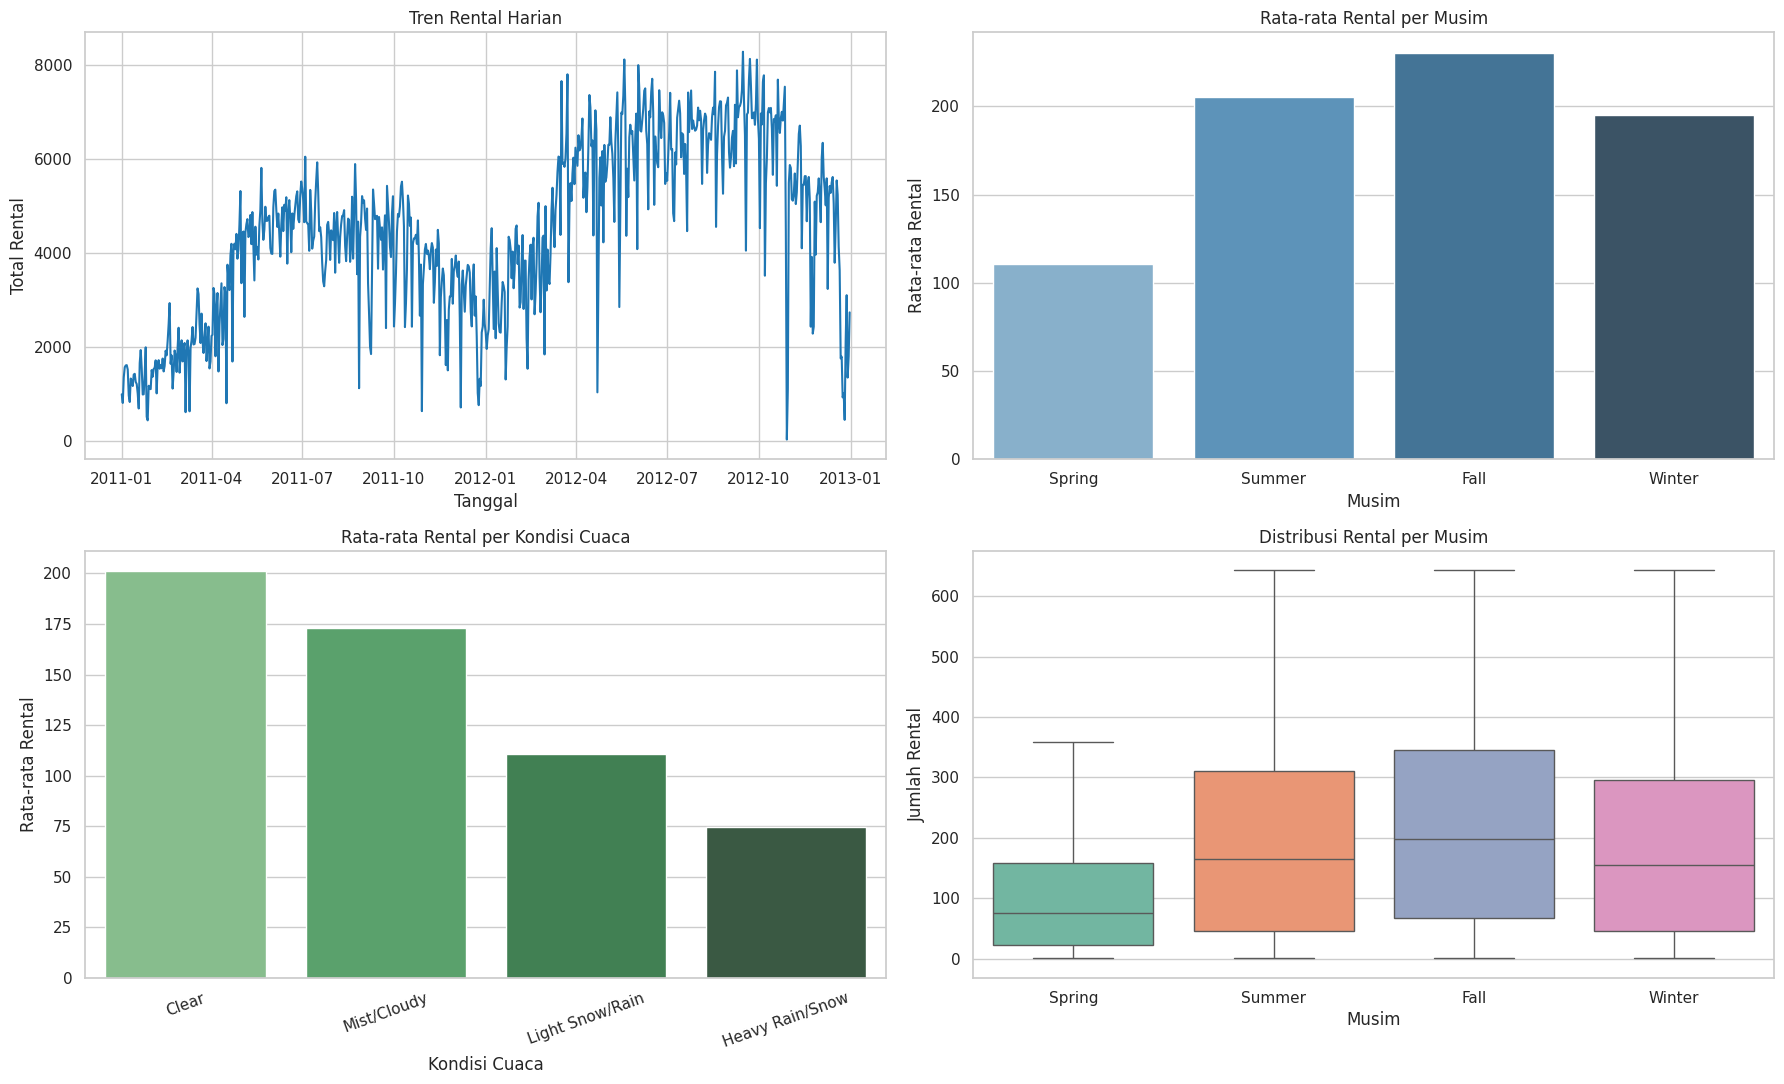

In [22]:
daily_trend = hour_clean.groupby('dteday', as_index=False)['cnt'].sum()
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = (
    hour_clean.groupby('season_name', as_index=False)['cnt']
    .mean()
)
season_avg['season_name'] = pd.Categorical(season_avg['season_name'], categories=season_order, ordered=True)
season_avg = season_avg.sort_values('season_name')

weather_avg = (
    hour_clean.groupby('weather_name', as_index=False)['cnt']
    .mean()
    .sort_values('cnt', ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.lineplot(data=daily_trend, x='dteday', y='cnt', color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Tren Rental Harian')
axes[0, 0].set_xlabel('Tanggal')
axes[0, 0].set_ylabel('Total Rental')

sns.barplot(data=season_avg, x='season_name', y='cnt', palette='Blues_d', ax=axes[0, 1])
axes[0, 1].set_title('Rata-rata Rental per Musim')
axes[0, 1].set_xlabel('Musim')
axes[0, 1].set_ylabel('Rata-rata Rental')

sns.barplot(data=weather_avg, x='weather_name', y='cnt', palette='Greens_d', ax=axes[1, 0])
axes[1, 0].set_title('Rata-rata Rental per Kondisi Cuaca')
axes[1, 0].set_xlabel('Kondisi Cuaca')
axes[1, 0].set_ylabel('Rata-rata Rental')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.boxplot(data=hour_clean, x='season_name', y='cnt', order=season_order, palette='Set2', showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title('Distribusi Rental per Musim')
axes[1, 1].set_xlabel('Musim')
axes[1, 1].set_ylabel('Jumlah Rental')

plt.tight_layout()
plt.show()


**Insight Pertanyaan 1:**
- Permintaan menunjukkan tren yang lebih tinggi pada musim **Fall** dan **Summer** dibandingkan **Spring**, mengindikasikan adanya pengaruh musiman terhadap tingkat penyewaan.

- Kondisi cuaca **Clear** mencatat rata-rata jumlah rental tertinggi, yang menunjukkan bahwa demand cukup sensitif terhadap faktor cuaca.

- Distribusi data per musim memperlihatkan variasi permintaan yang relatif lebar. Hal ini mengindikasikan perlunya strategi perencanaan dan alokasi armada yang adaptif terhadap perubahan pola musiman.

### Pertanyaan 2: Kapan waktu dengan tingkat penyewaan sepeda tertinggi, dan bagaimana perbedaannya antara hari kerja vs hari libur/akhir pekan?

Visualisasi yang digunakan:
- Bar chart rata-rata rental per jam untuk mengidentifikasi jam puncak.
- Line chart perbandingan pola jam pada hari kerja vs libur/akhir pekan.
- Heatmap korelasi untuk mendukung interpretasi hubungan antar variabel numerik.

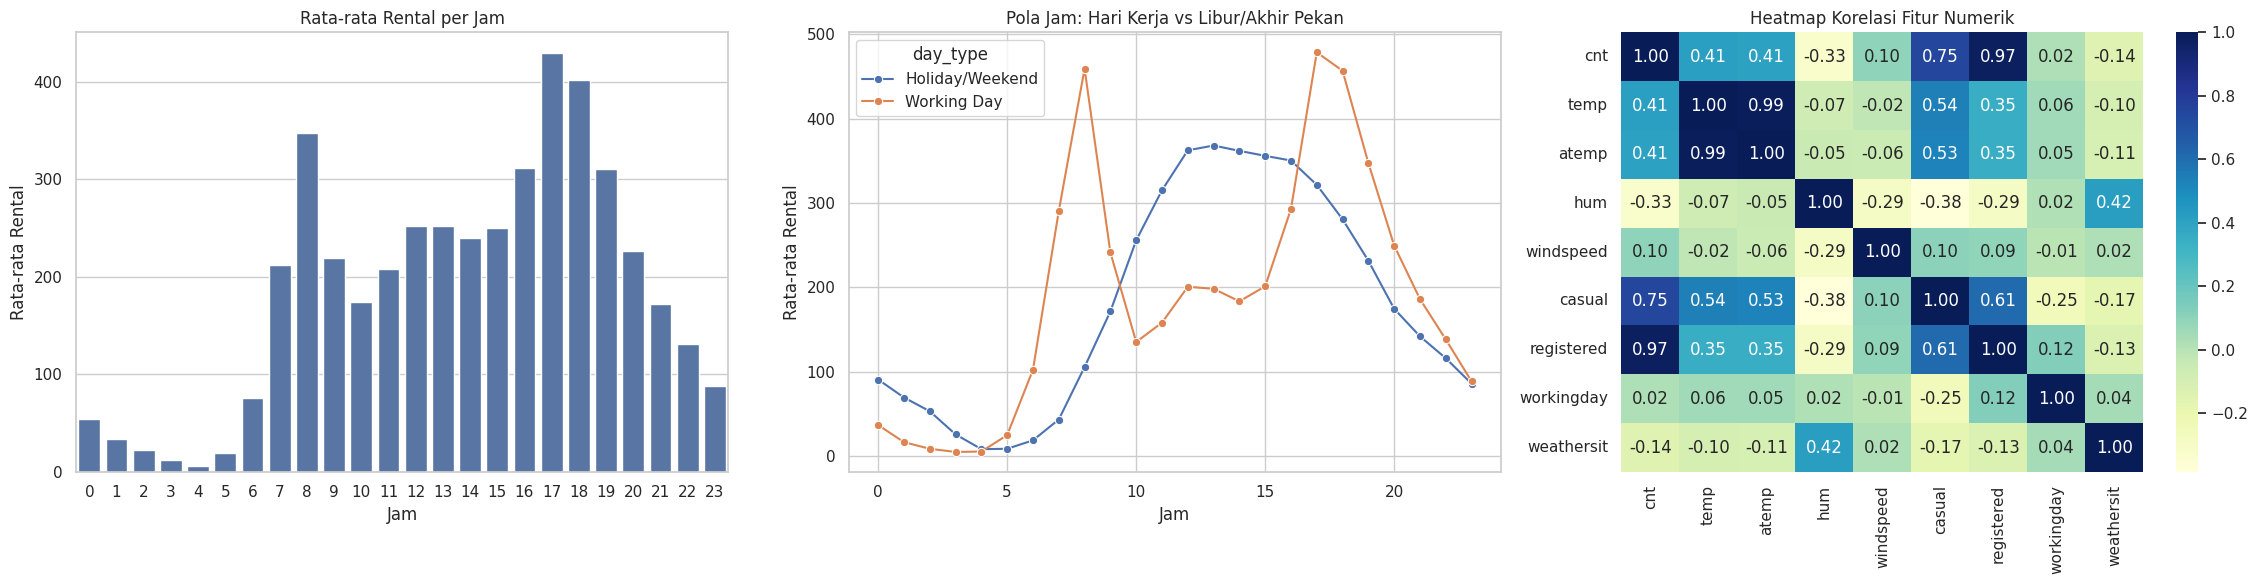

In [24]:
hourly_avg = hour_clean.groupby('hr', as_index=False)['cnt'].mean()

hourly_day_type = (
    hour_clean.groupby(['hr', 'day_type'], as_index=False)['cnt']
    .mean()
)

corr_cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'workingday', 'weathersit']
corr_matrix = hour_clean[corr_cols].corr(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(23, 6))

sns.barplot(data=hourly_avg, x='hr', y='cnt', color='#4C72B0', ax=axes[0])
axes[0].set_title('Rata-rata Rental per Jam')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Rata-rata Rental')

sns.lineplot(data=hourly_day_type, x='hr', y='cnt', hue='day_type', marker='o', ax=axes[1])
axes[1].set_title('Pola Jam: Hari Kerja vs Libur/Akhir Pekan')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata Rental')

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[2])
axes[2].set_title('Heatmap Korelasi Fitur Numerik')

plt.tight_layout()
plt.show()


**Insight:**
- Visualisasi menunjukkan bahwa permintaan meningkat secara bertahap dari pagi hingga sore hari, dengan **puncak utama pada pukul 17.00–18.00**, selaras dengan jam pulang kerja.

- Pada **hari kerja (weekday)** terlihat pola komuter yang kuat, ditandai dengan lonjakan permintaan pada pagi dan sore hari. Sebaliknya, **akhir pekan/hari libur** cenderung menunjukkan puncak permintaan pada siang hari, yang lebih mencerminkan aktivitas rekreasional.

- Hasil analisis korelasi menunjukkan bahwa variabel `registered` memiliki hubungan yang sangat kuat dan dominan terhadap total rental (`cnt`). Hal ini mengindikasikan bahwa **pengguna terdaftar merupakan kontributor utama terhadap volume penyewaan secara keseluruhan**.

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_1366/2520667758.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_clean.groupby('demand_cluster')['cnt']
/tmp/ipykernel_1366/2520667758.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hour_clean, x='demand_cluster', order=labels, palette='viridis', ax=axes[0])
/tmp/ipykernel_1366/2520667758.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hour_clean, x='demand_cluster', y='hr', order=labels, palette='viridis', showfliers=False, ax=axes[1])


Batas cluster demand:
Low   : 0 - 69.00
Medium: 69.00 - 221.00
High  : 221.00 - 642.50

Ringkasan cluster demand:
demand_cluster  count       mean   min   max
    Low Demand   5748  24.677279   1.0  69.0
 Medium Demand   5727 141.661952  70.0 221.0
   High Demand   5904 387.132537 222.0 642.5


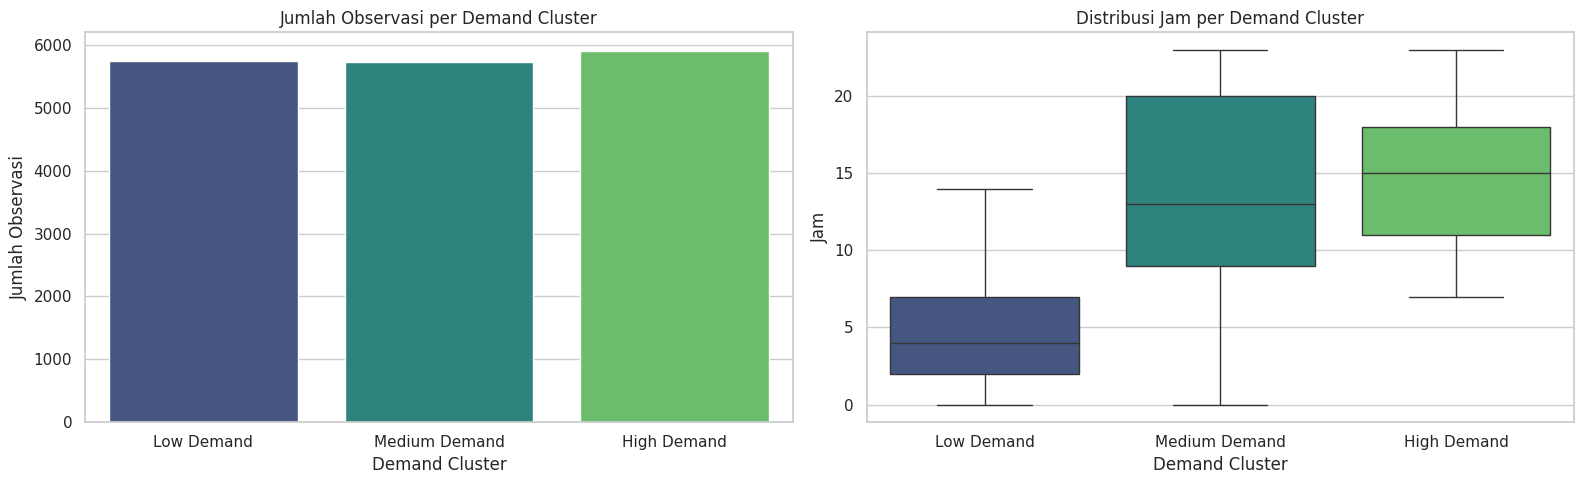

In [25]:
q33 = hour_clean['cnt'].quantile(0.33)
q66 = hour_clean['cnt'].quantile(0.66)
max_cnt = hour_clean['cnt'].max()

bins = [-1, q33, q66, max_cnt]
labels = ['Low Demand', 'Medium Demand', 'High Demand']

hour_clean['demand_cluster'] = pd.cut(hour_clean['cnt'], bins=bins, labels=labels)

cluster_summary = (
    hour_clean.groupby('demand_cluster')['cnt']
    .agg(['count', 'mean', 'min', 'max'])
    .reset_index()
)

print('Batas cluster demand:')
print(f'Low   : 0 - {q33:.2f}')
print(f'Medium: {q33:.2f} - {q66:.2f}')
print(f'High  : {q66:.2f} - {max_cnt:.2f}')

print()
print('Ringkasan cluster demand:')
print(cluster_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=hour_clean, x='demand_cluster', order=labels, palette='viridis', ax=axes[0])
axes[0].set_title('Jumlah Observasi per Demand Cluster')
axes[0].set_xlabel('Demand Cluster')
axes[0].set_ylabel('Jumlah Observasi')

sns.boxplot(data=hour_clean, x='demand_cluster', y='hr', order=labels, palette='viridis', showfliers=False, ax=axes[1])
axes[1].set_title('Distribusi Jam per Demand Cluster')
axes[1].set_xlabel('Demand Cluster')
axes[1].set_ylabel('Jam')

plt.tight_layout()
plt.show()


## Conclusion

## Kesimpulan Pertanyaan 1  

Analisis menunjukkan bahwa **musim dan kondisi cuaca memiliki pengaruh signifikan terhadap tingkat permintaan rental**. Periode **Fall dan Summer** mencatat rata-rata serta total jumlah rental tertinggi dibandingkan musim lainnya. Selain itu, **kondisi cuaca cerah** secara konsisten berkorelasi dengan peningkatan permintaan.  

Temuan ini mengindikasikan bahwa faktor musiman dan cuaca merupakan variabel kunci dalam memproyeksikan demand.

---

## Kesimpulan Pertanyaan 2  

Pola penggunaan menunjukkan adanya **jam puncak (peak hour) pada sore hari, khususnya sekitar pukul 17.00**.

- Pada **hari kerja (weekday)** terlihat pola komuter yang jelas, dengan lonjakan permintaan pada jam berangkat dan pulang kerja.  
- Pada **akhir pekan atau hari libur**, pola permintaan lebih terkonsentrasi pada siang hingga sore hari, mencerminkan penggunaan untuk aktivitas rekreasional.  

Hal ini menunjukkan adanya perbedaan karakteristik demand antara hari kerja dan hari libur.

---

## Analisis Lanjutan – Manual Binning Demand  

Melalui pendekatan **manual binning**, tingkat permintaan diklasifikasikan menjadi tiga kategori:

- **Low**
- **Medium**
- **High**

Segmentasi ini dapat dimanfaatkan untuk:

- Optimalisasi alokasi armada  
- Perencanaan kapasitas operasional per jam  
- Penyusunan strategi penjadwalan dan distribusi sumber daya  

